<a href="https://colab.research.google.com/github/pearl24680/-FACE-EMOTION-IMAGE-RECOGNITION-/blob/main/deepfakedetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
!pip install tensorflow opencv-python matplotlib transformers

In [35]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [36]:
!pip install kaggle

In [37]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"pearlsethi","key":"644b7b9a20629c3ad30f75c0c54bbb2b"}'}

In [38]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [39]:
# Download the data from the Kaggle
!kaggle datasets download -d xh

403 - Forbidden - Permission 'datasets.get' was denied


In [40]:
# Download the data from the Kaggle
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces
!unzip -q 140k-real-and-fake-faces.zip -d data/

Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
140k-real-and-fake-faces.zip: Skipping, found more recently modified local copy (use --force to force download)
replace data/real_vs_fake/real-vs-fake/test/fake/00276TOPP4.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [41]:
#Deal with data

base_path = "/content/data/real_vs_fake/real-vs-fake/"
train_path = os.path.join(base_path, "train")
test_path = os.path.join(base_path, "test")
valid_path = os.path.join(base_path, "valid")

In [42]:
print("Training real images: ", len(os.listdir(os.path.join(train_path, "real"))))
print("Training fake images: ", len(os.listdir(os.path.join(train_path, "fake"))))
print("Testing real images: ", len(os.listdir(os.path.join(test_path, "real"))))
print("Testing fake images: ", len(os.listdir(os.path.join(test_path, "fake"))))


Training real images:  50000
Training fake images:  50000
Testing real images:  10000
Testing fake images:  10000


In [43]:
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(128,128,3))
base_model.trainable = False


In [44]:
#Building the model

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
   Dense(128, activation='relu'),
    Dense(1, activation='sigmoid'),

])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)          │ (None, 4, 4, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_3           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [45]:
datagen = ImageDataGenerator(rescale=1./255)
train_generator = datagen.flow_from_directory(
    train_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

Found 100000 images belonging to 2 classes.


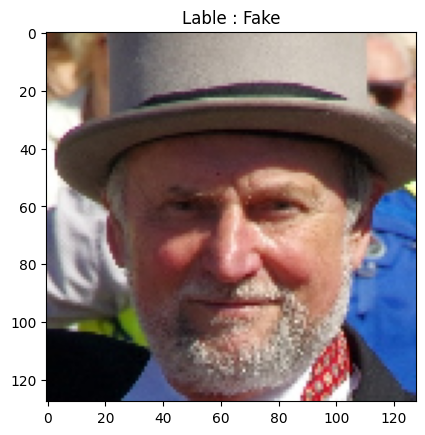

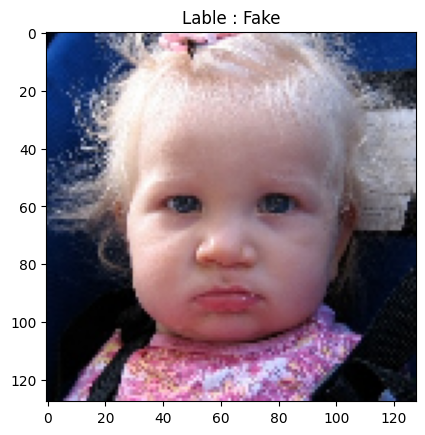

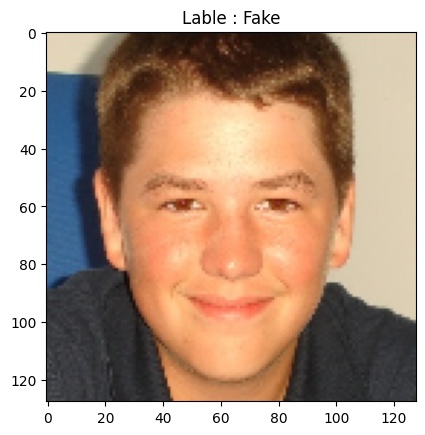

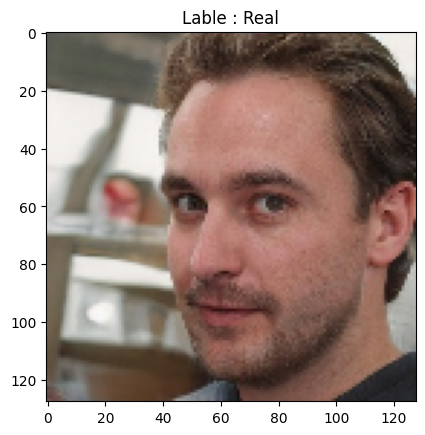

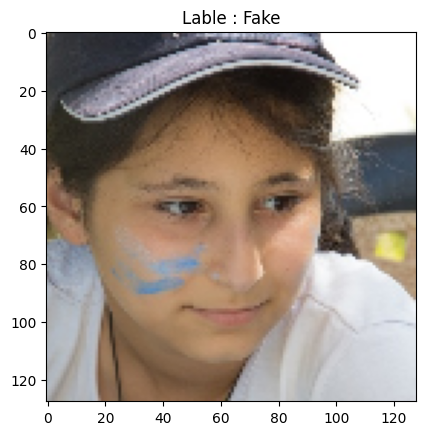

In [46]:
for images, labels in train_generator:
    for i in range(5):
      plt.imshow(images[i])
      plt.title(f"Lable : { 'Real' if labels[i]==0 else 'Fake'}")
      plt.show()

    break

In [50]:
# ... previous code ...
datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_directory(
    train_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

# Define valid_gen similar to train_generator, using valid_path
valid_gen = datagen.flow_from_directory(
    valid_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)
# ... rest of the code ...

history = model.fit(
    train_generator,
    validation_data=valid_gen,  # valid_gen is now defined
    epochs=5,
    steps_per_epoch = train_generator.samples // 32,
    validation_steps = valid_gen.samples // 32
)

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Epoch 1/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 3052s 977ms/step - accuracy: 0.5006 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/5


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 3/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 3140s 1s/step - accuracy: 0.5012 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 5/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 3114s 996ms/step - accuracy: 0.4970 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932


In [3]:
import cv2
import numpy as np

def preprocess_image(image_path):
  """Loads and preprocesses an image for prediction."""
  img = cv2.imread(image_path)
  img = cv2.resize(img, (128, 128))  # Resize to match model input
  img = img / 255.0  # Rescale pixel values
  img = np.expand_dims(img, axis=0)  # Add batch dimension
  return img

# Replace 'path/to/your/test/image.jpg' with the actual path
image_path = '/content/download (3).jpeg'
processed_image = preprocess_image(image_path) # This line is crucial
# Make prediction
prediction = model.predict(processed_image)

# Interpret prediction
if prediction < 0.5:
    print("The image is predicted to be real.")
else:
    print("The image is predicted to be fake.")


#Check the accuracy on the test data
datagen = ImageDataGenerator(rescale=1./255)
test_generator = datagen.flow_from_directory(
    test_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)
# Evaluate the model
loss, accuracy = model.evaluate(test_generator)
print(f"Test accuracy: {accuracy}")

NameError: name 'model' is not defined